In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from config import config
from utils.common import extract_latents
from run_models import run_VAE, run_KMeans, run_Agglomerative, run_DBSCAN

d:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import torch, numpy as np
from pathlib import Path

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [5]:
root = Path("../..")

### check that config.VAE_TYPE = "conv" and config.MODEL_TYPE = "cvae"

In [8]:
config.VAE_TYPE, config.MODEL_TYPE

('conv', 'cvae')

In [9]:
cvae, latent_dim, train_loader, test_loader, vae_history, study = run_VAE(model_type="cvae", root=root, plot_dir_name="hard_1_cvae_audio_only")

[I 2026-04-10 08:50:49,120] A new study created in memory with name: Conditional VAE Tuning


Creating fresh trials directory...


  0%|          | 0/5 [00:00<?, ?it/s]

--------------------------------------------------
Epoch 1 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 373.4140     | 234.8867    
Recon        | 321.8342     | 228.4152    
KL Div       | 257.8989     | 32.3576     
--------------------------------------------------

--------------------------------------------------
Epoch 2 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 341.8767     | 212.4409    
Recon        | 255.9277     | 200.5475    
KL Div       | 429.7446     | 59.4672     
--------------------------------------------------

--------------------------------------------------
Epoch 3 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 183.0651     | 143.8731    
Recon        | 169.3891     | 133.4137    
KL Div       | 68.3801      | 52.2971     
--------------------------------------

  0%|          | 0/5 [00:06<?, ?it/s]

...

--------------------------------------------------
Epoch 1 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 207.5273     | 125.6210    
Recon        | 190.5075     | 113.8121    
KL Div       | 85.0993      | 59.0445     
--------------------------------------------------

--------------------------------------------------
Epoch 2 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 100.0944     | 86.6235     
Recon        | 89.1068      | 77.0582     
KL Div       | 54.9382      | 47.8263     
--------------------------------------------------

--------------------------------------------------
Epoch 3 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 76.9624      | 70.9889     
Recon        | 66.6906      | 60.8739     
KL Div       | 51.3590      | 50.5750     
--------------------------------------

Best trial: 1. Best value: 67.3807:  80%|████████  | 4/5 [01:19<00:16, 16.98s/it]

--------------------------------------------------
Epoch 5 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 64.1897      | 66.0767     
Recon        | 54.9970      | 56.2393     
KL Div       | 45.9631      | 49.1869     
--------------------------------------------------

[I 2026-04-10 08:52:08,937] Trial 4 finished with value: 53.4183246415915 and parameters: {'CHANNEL_1': 8, 'CHANNEL_2_MULTIPLIER': 2, 'CHANNEL_3_MULTIPLIER': 4, 'LATENT_DIM': 32, 'LR': 0.0002572663133249957, 'BATCH_SIZE': 16, 'BETA': 3.0}. Best is trial 4 with value: 53.4183246415915.


Best trial: 4. Best value: 53.4183: 100%|██████████| 5/5 [01:20<00:00, 16.00s/it]


..\..\results\trials\hard_1_cvae_audio_only\plots
Saved: ..\..\results\trials\hard_1_cvae_audio_only\plots\optimization_history.html
Saved: ..\..\results\trials\hard_1_cvae_audio_only\plots\param_importances.html
Saved: ..\..\results\trials\hard_1_cvae_audio_only\plots\parallel_coordinate.html
Saved: ..\..\results\trials\hard_1_cvae_audio_only\plots\edf.html
Saved: ..\..\results\trials\hard_1_cvae_audio_only\plots\timeline.html
Saved: ..\..\results\trials\hard_1_cvae_audio_only\plots\contour.html
Best trial for `cvae`:
Score: 53.4183
    CHANNEL_1                 8
    CHANNEL_2_MULTIPLIER      2
    CHANNEL_3_MULTIPLIER      4
    LATENT_DIM                32
    LR                        0.0002572663133249957
    BATCH_SIZE                16
    BETA                      3.0


FINAL MODEL:
 VAE(
  (encoder): Encoder(
    (net): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track

In [10]:
train_latents, train_labels = extract_latents(model=cvae, loader=train_loader, device=device)
test_latents,  test_labels  = extract_latents(model=cvae, loader=test_loader,  device=device)

In [11]:
vae_latents = np.concatenate([train_latents, test_latents], axis=0)
vae_labels  = np.concatenate([train_labels,  test_labels],  axis=0)

In [12]:
set(list(vae_labels))

{np.int64(0), np.int64(1), np.int64(2), np.int64(3)}




Optimal k        : 5
Inertia (WCSS)   : 44820.8828
Silhouette Score : 0.2143
CH Index         : 553.2790
DB Index         : 1.5132
ARI              : 0.0598
NMI              : 0.0751
Purity           : 0.3758



n_clusters not provided for Agglomerative — running elbow method to determine k...



Agglomerative  n_clusters=5  linkage='ward'
Silhouette Score : 0.1536
CH Index         : 444.6901
DB Index         : 1.5753
ARI              : 0.0347
NMI              : 0.0624
Purity           : 0.3474






DBSCAN  eps=2.5  min_samples=5
Clusters found   : 9
Noise points     : 1377



DB-SCAN
Silhouette Score : -0.0971
CH Index         : 109.6182
DB Index         : 1.4424
ARI              : -0.0035
NMI              : 0.0692
Purity           : 0.4250





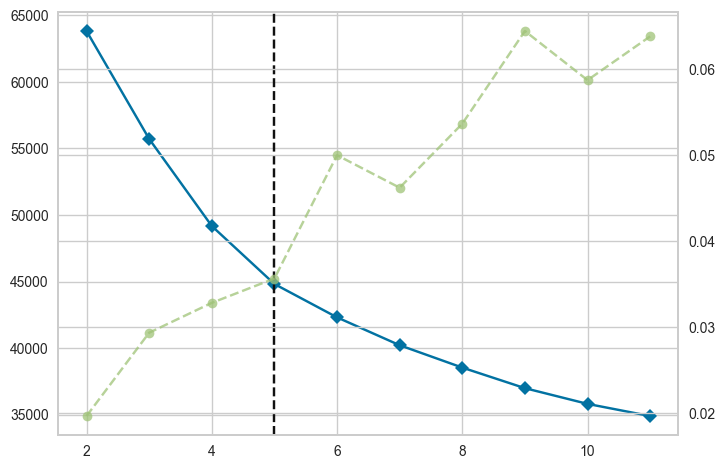

In [13]:
vae_kmeans, vae_kmeans_metrics = run_KMeans(vae_latents, model_type="hard_1_cvae_audio_only", root=root, true_labels=vae_labels)
vae_agglomerative, vae_agglomerative_metrics = run_Agglomerative(vae_latents, model_type="hard_1_cvae_audio_only", root=root, true_labels=vae_labels)
vae_dbscan, vae_dbscan_metrics = run_DBSCAN(vae_latents, model_type="hard_1_cvae_audio_only", root=root, true_labels=vae_labels)

In [14]:
from collections import Counter

for cluster_id in range(len(vae_kmeans.cluster_centers_)):
    mask = vae_kmeans.labels_ == cluster_id
    genre_counts = Counter(vae_labels[mask])
    print(f"Cluster {cluster_id}: {genre_counts}")

Cluster 0: Counter({np.int64(0): 271, np.int64(1): 267, np.int64(3): 104, np.int64(2): 91})
Cluster 1: Counter({np.int64(1): 173, np.int64(3): 101, np.int64(0): 69, np.int64(2): 56})
Cluster 2: Counter({np.int64(2): 139, np.int64(3): 114, np.int64(0): 39, np.int64(1): 8})
Cluster 3: Counter({np.int64(2): 277, np.int64(3): 244, np.int64(0): 179, np.int64(1): 102})
Cluster 4: Counter({np.int64(1): 51, np.int64(0): 49, np.int64(2): 47, np.int64(3): 43})


In [15]:
from visualizations import plot_tsne_clustering_comparison
from sklearn.metrics import silhouette_score

In [16]:
TSNE_DIR = root / config.TSNE_DIR
TSNE_DIR.mkdir(exist_ok=True, parents=True)

Computing t-SNE embeddings (this may take a minute)...
Saved → ..\..\results\clustering\tsne\hard_1_cvae_audio_only


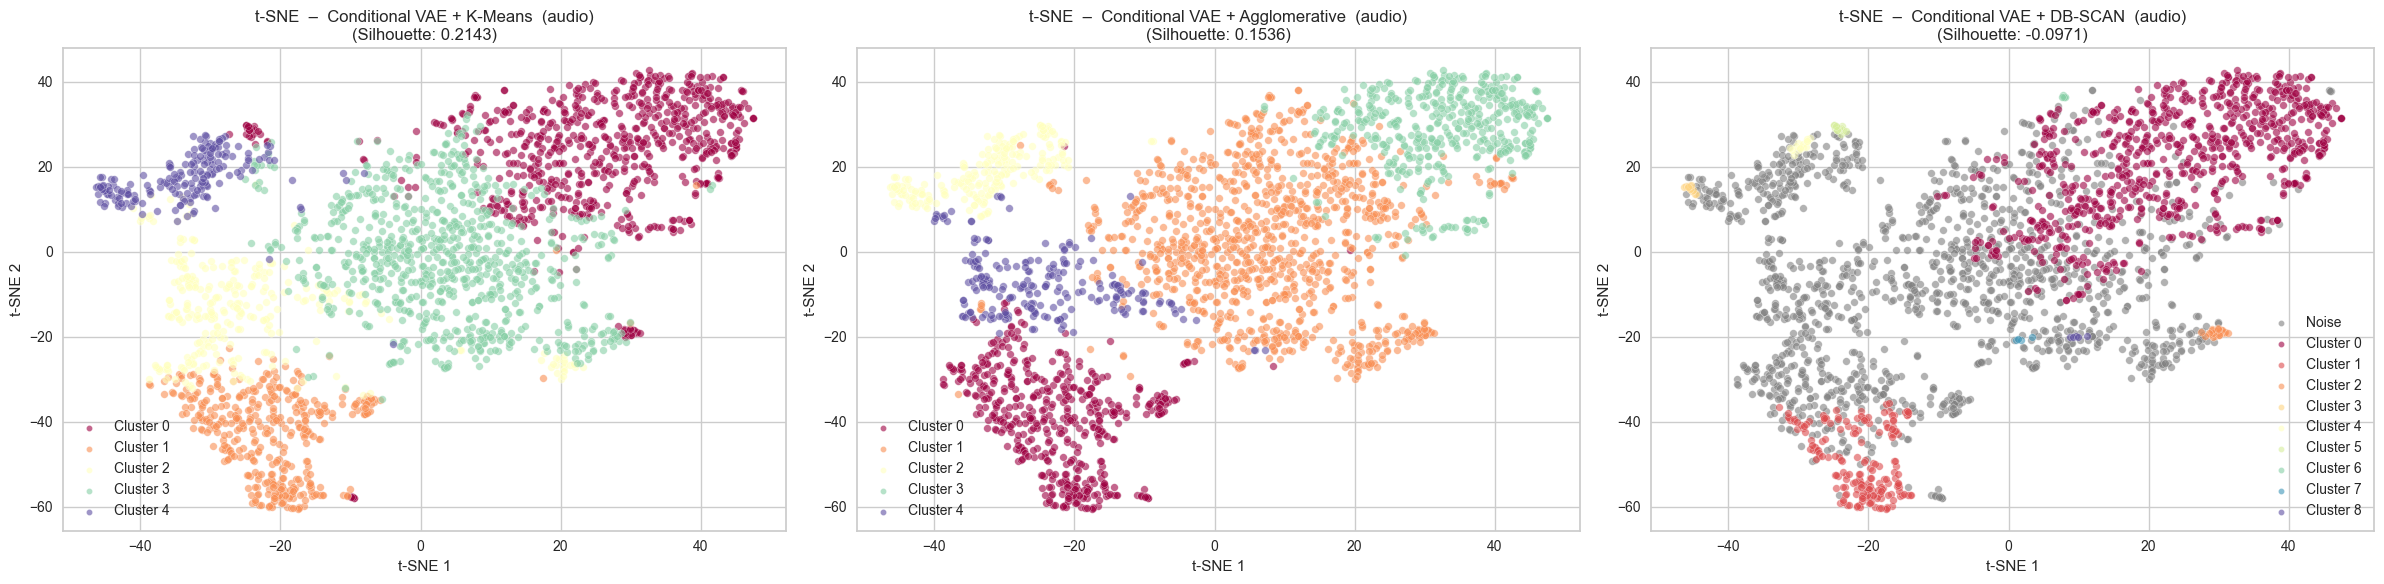

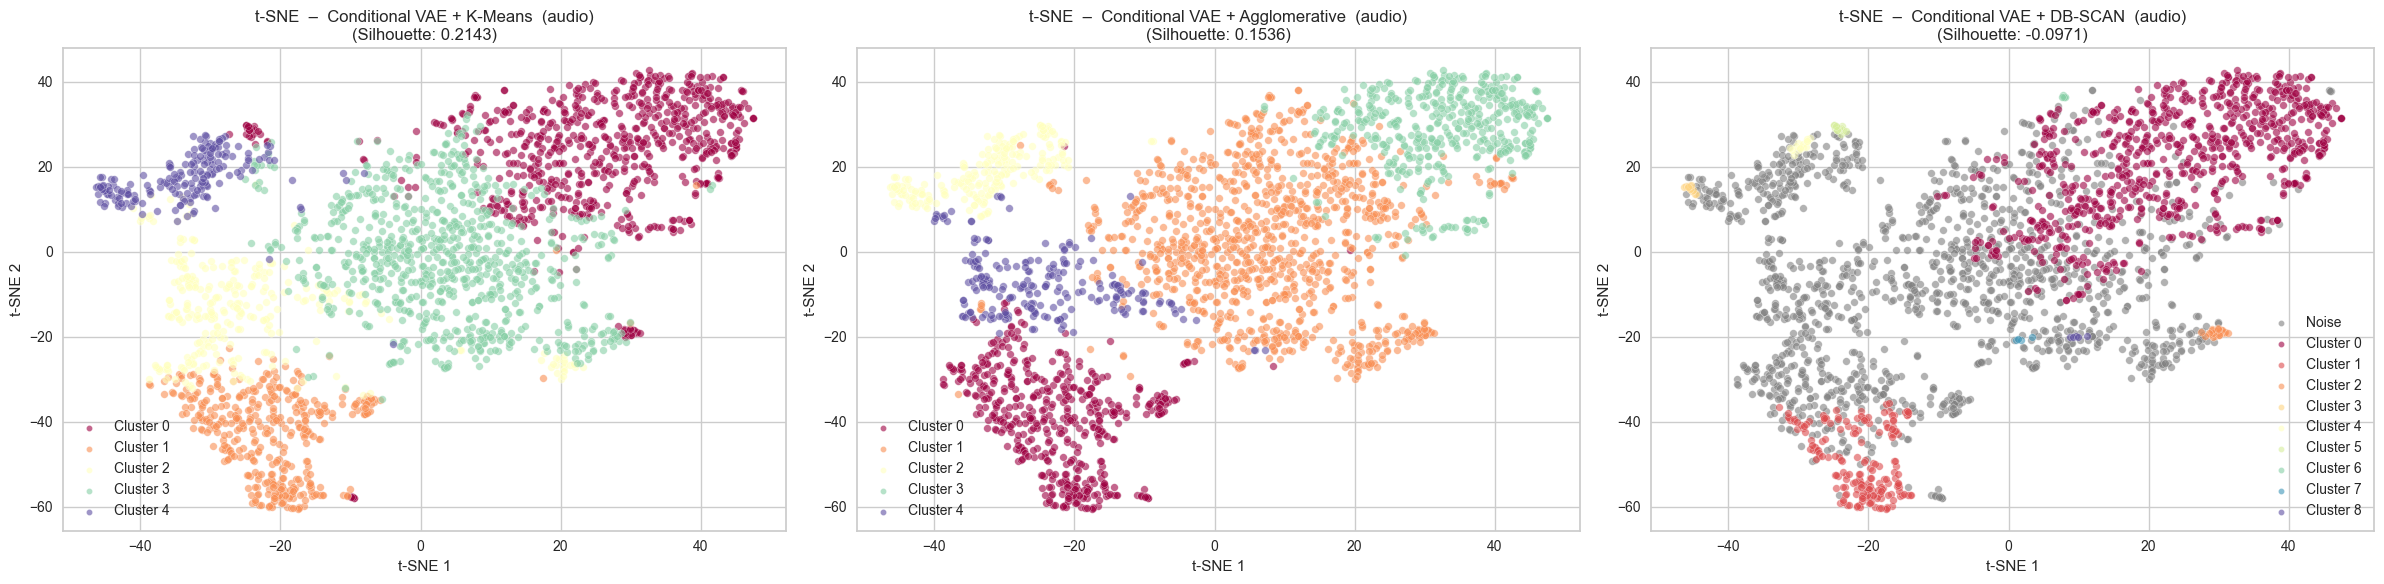

In [17]:
plot_tsne_clustering_comparison(
    vae_latents,
    [vae_kmeans.labels_, vae_agglomerative.labels_, vae_dbscan.labels_],
    ["Conditional VAE + K-Means  (audio)", "Conditional VAE + Agglomerative  (audio)", "Conditional VAE + DB-SCAN  (audio)"],
    scores=[silhouette_score(vae_latents, vae_kmeans.labels_), silhouette_score(vae_latents, vae_agglomerative.labels_), silhouette_score(vae_latents, vae_dbscan.labels_)],
    save_path=TSNE_DIR / "hard_1_cvae_audio_only"
)